![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site 10020100 Woodruff Narrows Reservoir
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge above Woodruff Narrows Reservoir.

In [1]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Define the watershed outlet using NWIS site id. Create a map object that we'll add layers to.

In [10]:
nldi = NLDI()
usgs_gage_id = "10020100" # NWIS id for Bear river at the inlet of Woodruff Narrows Reservoir
WY = 2024 # Water Year to analyze. A water year is defined as the 12 month period from October 1st to September 30th.

Collect watershed and reach vectors using the pynhd module.

In [11]:
#Getting basin geometry
basinname ='BearRiverBasin'

print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file(f"files/{basinname}.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

Create and interactive map to display the watershed.

In [12]:
# create map, having trouble showigng the map? Does "Make this Notebook Trusted to load map" appear?
#cd to the directy and run jupyter trust Snotel.ipynb
mapping.basin_mapping(basin, site_feature)

# 2. Identify SNOTEL sites within a spatial domain

Here, we will read a geojson file from the web containing the geospatial information for all SNOTEL sites. 
Once loaded, the script will use the basin geometry (in the form of a polygon in the GeoDataFrame) to clip all SNOTEL sites located within the boundaries of the basin.

In [13]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry.iloc[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,992_UT_SNTL,Bear River RS,SNOTEL,2675.229492,40.885201,-110.827698,Utah,160101010106,12TWL,Western Rocky Mountains,2010-10-28,2026-03-25,True,POINT (-110.8277 40.8852)
1,1135_UT_SNTL,Burts Miller Ranch,SNOTEL,2438.399902,40.984921,-110.850754,Utah,160101010105,12TWL,None,2009-10-01,2026-03-25,True,POINT (-110.85075 40.98492)
2,517_UT_SNTL,Hayden Fork,SNOTEL,2782.823975,40.796692,-110.884720,Utah,160101010101,12TWL,Western Rocky Mountains,1978-10-01,2026-03-25,True,POINT (-110.88472 40.79669)
3,579_UT_SNTL,Lily Lake,SNOTEL,2783.738281,40.864929,-110.798126,Utah,160101010103,12TWL,Western Rocky Mountains,1980-06-12,2026-03-25,True,POINT (-110.79813 40.86493)


Add the SNOTEL monitoring station locations to the map

In [14]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

# 3. Retrieve data for the selected sites

The following uses the [getData.py](./supporting_scripts/getData.py) script to download SNOTEL data for the sites within the domain. Inputs to this script include the SNOTEL site name, site ID, and state abbreviation, which are retrieved from the geodataframe above. Additional inputs include the start and end dates, as well as the path to save the outputs.

In [15]:
# Use the getData module to retrieve data 
OutputFolder = 'files/SNOTEL'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

for i in gdf_in_bbox.index:
    getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], 'UT', gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)
    #getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)


Start retrieving data for Bear River RS, 992_UT_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/992:UT:SNTL%7Cid=%22%22%7Cname/2010-10-28,2026-03-25/WTEQ::value?fitToScreen=false


MaxRetryError: HTTPSConnectionPool(host='wcc.sc.egov.usda.gov', port=443): Max retries exceeded with url: /reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/992:UT:SNTL%7Cid=%22%22%7Cname/2010-10-28,2026-03-25/WTEQ::value?fitToScreen=false (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1017)')))

# 4.  Process the data to enable plotting and analysis

In [10]:
# Load the data for one site
sites = list(gdf_in_bbox.code)
stateab = 'UT'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)

# Check the first site loaded correctly
first_site = sites[0]
print(first_site)
sitedict[first_site].head()

992_UT_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
1135_UT_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
517_UT_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
579_UT_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
992_UT_SNTL


,M,D,2011_SWE_in,2012_SWE_in,2013_SWE_in,2014_SWE_in,2015_SWE_in,2016_SWE_in,2017_SWE_in,2018_SWE_in,...,2026_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,1.200001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.08,0.0,0.0,0.0,1.200001,2023-10-01
10-02,10,2,1.200001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.08,0.0,0.0,0.0,1.200001,2023-10-02
10-03,10,3,1.200001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.08,0.0,0.0,0.0,1.200001,2023-10-03
10-04,10,4,1.200001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.08,0.0,0.0,0.0,1.200001,2023-10-04
10-05,10,5,1.200001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.08,0.0,0.0,0.0,1.200001,2023-10-05


# 5. Make a snow report for WY2025

We use the script [SNOTEL_Analyzer](./supporting_scripts/SNOTEL_Analyzer.py) **SNOTELPlots()** function to generate a plot of all snotel sites of interest. The function takes in the following inputs:
* A dictionary of sites - if you only have one site, that is fine but it still needs to be in a dictionary
* geodataframe with a bounding box from the above step
* A water year (WY) of interest
* An Area of Interest (AOI) name
* Day of interest (DOI). This makes the dashed vline and establishes the statistics

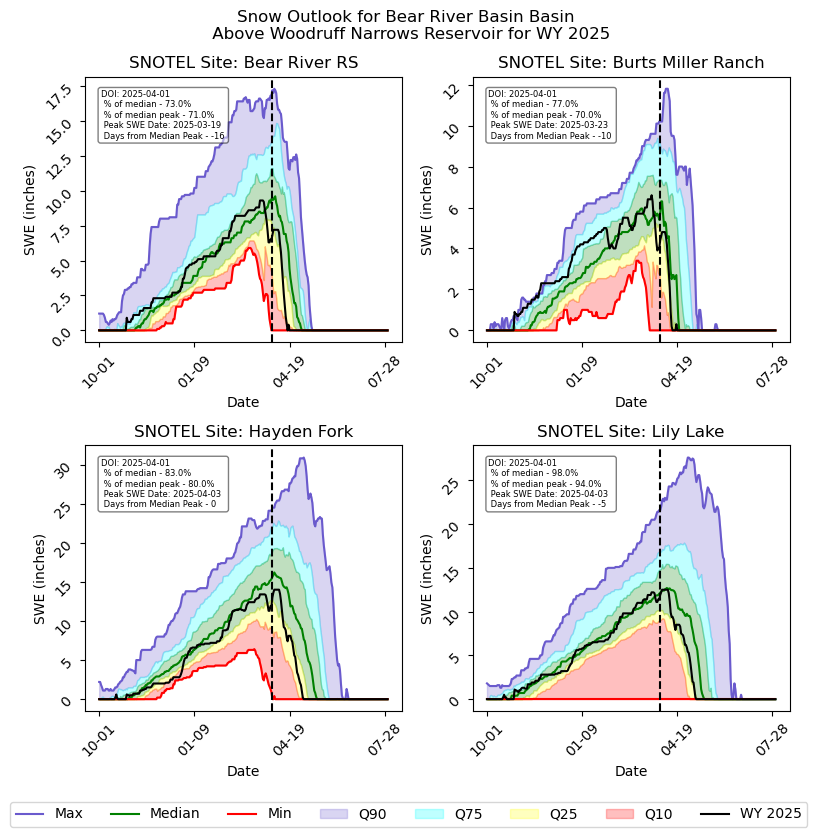

In [11]:
watershed = "Bear River Basin"
AOI = 'Above Woodruff Narrows Reservoir'
DOI = '04-01' #must be in MM-DD form
SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI,DOI)

# 6. Generate a Basin Snow report

By using the [SNOTEL_Analyzer](./supporting_scripts/SNOTEL_Analyzer.py) **catchmentSNOTELAnalysis()** function, the user will be able to develop a statistical snow analysis based on the mean values of each SNOTEL observation station within the catchment.

The function takes in the following inputs:
**A dictionary of sites - if you only have one site, that is fine but it still needs to be in a dictionary
* A water year (WY) of interest
* An Area of Interest (AOI) name
* Day of interest (DOI). This makes the dashed vline and establishes the statistics

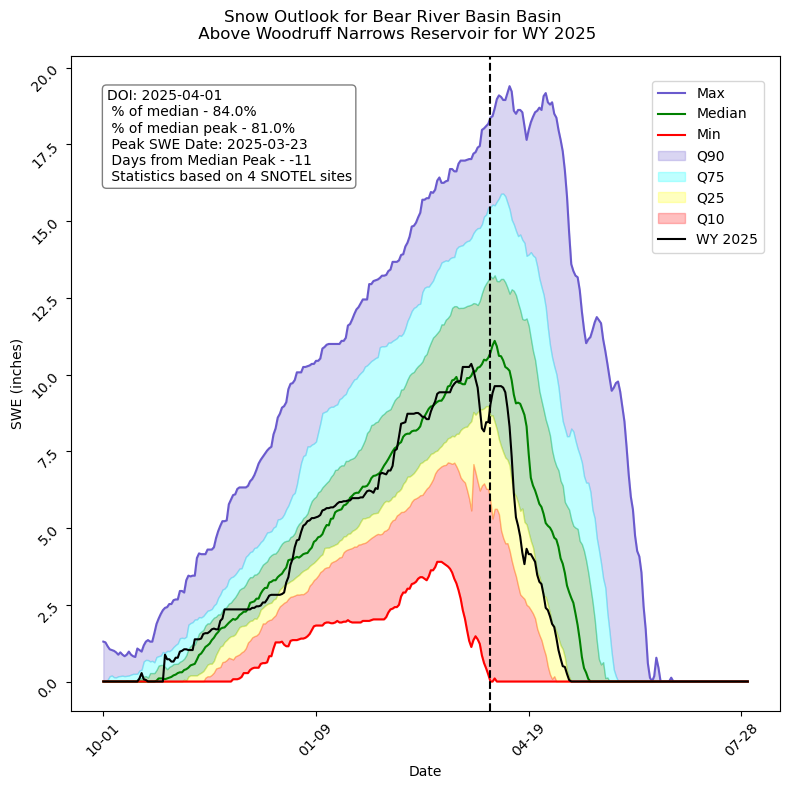

In [12]:
watershed = "Bear River Basin"
AOI = 'Above Woodruff Narrows Reservoir'
DOI = '04-01' #must be in MM-DD form

SNOTEL_Analyzer.catchmentSNOTELAnalysis(sitedict, WY, watershed, AOI, DOI)

## Getting additional data, Lets go from Snow to Flow!

Lets grab streamflow data using the USGS NWIS Data retrieval script and the dates of SNOTEL data





In [13]:
#use the dates for snotel data availability
gdf_in_bbox.head()

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,992_UT_SNTL,Bear River RS,SNOTEL,2675.229492,40.885201,-110.827698,Utah,160101010106,12TWL,Western Rocky Mountains,2010-10-28,2026-03-23,True,POINT (-110.8277 40.8852)
1,1135_UT_SNTL,Burts Miller Ranch,SNOTEL,2438.399902,40.984921,-110.850754,Utah,160101010105,12TWL,None,2009-10-01,2026-03-23,True,POINT (-110.85075 40.98492)
2,517_UT_SNTL,Hayden Fork,SNOTEL,2782.823975,40.796692,-110.884720,Utah,160101010101,12TWL,Western Rocky Mountains,1978-10-01,2026-03-23,True,POINT (-110.88472 40.79669)
3,579_UT_SNTL,Lily Lake,SNOTEL,2783.738281,40.864929,-110.798126,Utah,160101010103,12TWL,Western Rocky Mountains,1980-06-12,2026-03-23,True,POINT (-110.79813 40.86493)


In [14]:
gdf_in_bbox.beginDate.max()

'2010-10-28'

In [16]:
begin = gdf_in_bbox.beginDate.max()
end = gdf_in_bbox.endDate.min()
streamflow = getData.get_usgs_streamflow(usgs_gage_id, begin, end)

Retrieving data for Site: 10020100 from 2010-10-28 to 2026-03-25...


In [17]:
streamflow.head()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2010-10-28 00:00:00+00:00,10020100,46.5,A
2010-10-29 00:00:00+00:00,10020100,38.0,A
2010-10-30 00:00:00+00:00,10020100,36.4,A
2010-10-31 00:00:00+00:00,10020100,43.7,A
2010-11-01 00:00:00+00:00,10020100,50.3,A


In [18]:
streamflow.tail()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2026-03-21 00:00:00+00:00,10020100,52.6,P
2026-03-22 00:00:00+00:00,10020100,72.7,P
2026-03-23 00:00:00+00:00,10020100,98.1,P
2026-03-24 00:00:00+00:00,10020100,97.0,P
2026-03-25 00:00:00+00:00,10020100,128.0,P


## Clean the data

We need to change the index to a datetime indexand clean it to just the date. We do not need the 00060_Mean_cd column, and we should change it to streamflow in cfs

In [19]:
cleaned = dataprocessing.clean_nwis_dataframe(streamflow)
#set the index name to Date
cleaned.index.name = "Date"
cleaned.head()

,site_no,flow_cfs
Date,,
2010-10-28,10020100,46.5
2010-10-29,10020100,38.0
2010-10-30,10020100,36.4
2010-10-31,10020100,43.7
2010-11-01,10020100,50.3


In [20]:
#our other measurements are all in SI units, lets convert cfs to cms
cleaned['flow_cfs'] = cleaned['flow_cfs'] * 0.0283168
cleaned.rename(columns={'flow_cfs': 'flow_cms'}, inplace=True)

## Plot the data


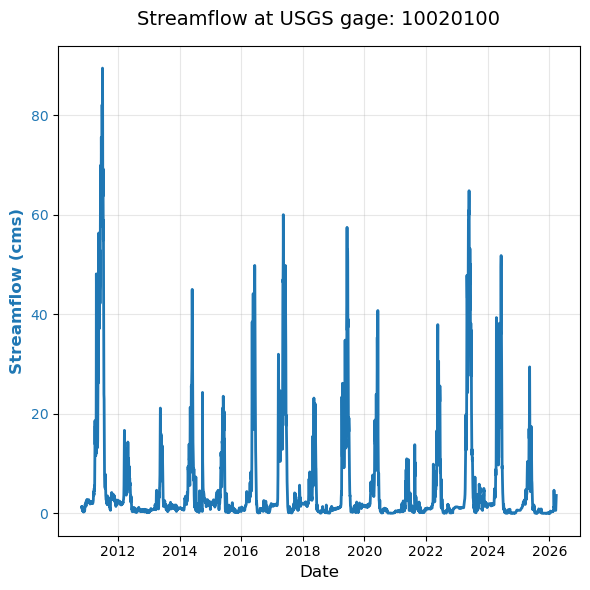

In [21]:
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: Streamflow ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Streamflow (cms)', color='tab:blue', fontsize=12, fontweight='bold')
ax1.plot(cleaned.index, cleaned['flow_cms'], color='tab:blue', label='Streamflow', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Title and Layout
plt.title('Streamflow at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()

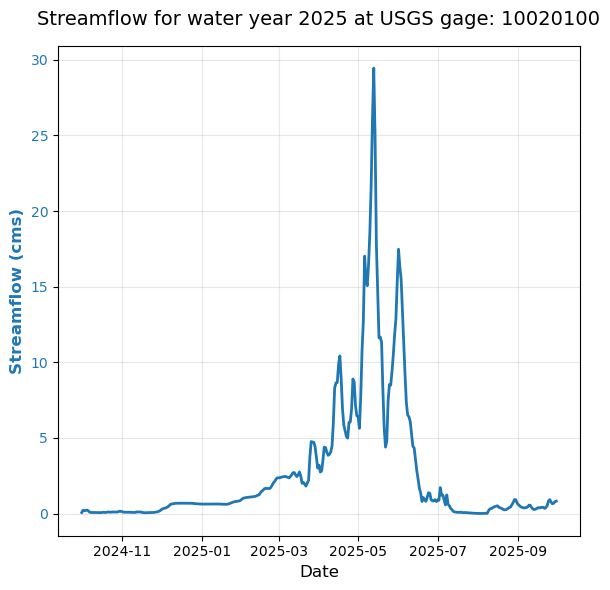

In [22]:
#clip the dataframe to show one single year
start = '2024-10-01'
end = '2025-09-30'
WY_df = cleaned.loc[start:end]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: Streamflow ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Streamflow (cms)', color='tab:blue', fontsize=12, fontweight='bold')
ax1.plot(WY_df.index, WY_df['flow_cms'], color='tab:blue', label='Streamflow', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Title and Layout
plt.title('Streamflow for water year 2025 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()

## Get precipitation and temperature data for our area of interest using PyDayMet

In [23]:
import earthaccess
from pynhd import NLDI
import pydaymet as daymet

# Authenticate with NASA
earthaccess.login(persist=True)

# Get basin geometry
basin = NLDI().get_basins(usgs_gage_id)
basin = basin.to_crs("EPSG:4326")

# Extract centroid coordinates
centroid = basin.geometry.centroid.iloc[0]
coords = (centroid.x, centroid.y)  # (lon, lat)
print(f"Basin centroid: {coords}")

# Date range
start_date = cleaned.index[0].strftime('%Y-%m-%d')
end_date = cleaned.index[-1].strftime('%Y-%m-%d')
if end_date > "2025-12-31":
    end_date = "2025-12-31"

dates = (start_date, end_date)
var = ["prcp", "tmin", "tmax"]

# get_bycoords works, get_bygeom is broken due to NASA EarthData migration
daily = daymet.get_bycoords(coords, dates=dates, variables=var)

print(daily.head())
print(daily.tail())



Basin centroid: (-110.904781283691, 41.066991343377104)
            prcp (mm/day)  tmax (degrees C)  tmin (degrees C)
time                                                         
1980-01-01           1.69              3.11             -5.93
1980-01-02           0.00              1.48             -8.24
1980-01-03           0.00              0.77            -13.98
1980-01-04           0.00              5.33             -3.01
1980-01-05           0.00              7.93             -6.89
            prcp (mm/day)  tmax (degrees C)  tmin (degrees C)
time                                                         
2024-12-26           1.88              1.50             -9.82
2024-12-27           5.03              1.94             -7.77
2024-12-28           1.70              2.63             -3.63
2024-12-29           5.95              6.17             -3.28
2024-12-30           3.68             -2.00            -16.55


In [24]:
import earthaccess # note, you may need to create a .netrc file in you home directory with the following information
from pynhd import NLDI
import pydaymet as daymet

#Authenticate with NASA (only needed once per session)
earthaccess.login(persist=True)

#Get geometry and ensure CRS is correct
basin = NLDI().get_basins(usgs_gage_id)
geometry_centroid = basin.to_crs("EPSG:4326").geometry[0].centroid
centroid = (geometry_centroid.x, geometry_centroid.y)

var = ["prcp", "tmin", "tmax"]
dates = (cleaned.index[0].strftime('%Y-%m-%d') , cleaned.index[-1].strftime('%Y-%m-%d') ) # Use the streamflow to determine dates

#Fetch data - authentication now happens automatically via earthaccess/.netrc
# Try this simplified call first
met_df = daymet.get_bycoords(centroid, dates, variables=["prcp", "tmin", "tmax"])



In [25]:
# clean the dataframe, rename the columns
met_df.rename(columns={"prcp (mm/day)": "prcp_mm_day", "tmin (degrees C)": "tmin_C", "tmax (degrees C)": "tmax_C"}, inplace=True)
#Calculate Mean Temperature
met_df["tmean"] = (met_df.tmax_C + met_df.tmin_C) / 2

#clip the dataframe by the streamflow dates
met_df = met_df.loc[cleaned.index[0]:cleaned.index[-1]]

#set the index to name to date
met_df.index.name = "Date"

met_df.head()


,prcp_mm_day,tmax_C,tmin_C,tmean
Date,,,,
2010-10-28,0.00,7.27,-8.63,-0.680
2010-10-29,0.00,12.47,-0.04,6.215
2010-10-30,5.02,11.49,-1.11,5.190
2010-10-31,1.88,6.64,-0.18,3.230
2010-11-01,0.00,9.51,-3.88,2.815


## Put it all together into one dataframe

We want to create one data frame containing streamflow, meteological information, and SNOTEL for our period of record

In [26]:
#load snotel data
unprocessed_SNOTEL = {}
#read all files in the following path into the dictionary
path = 'files/SNOTEL'
for filename in os.listdir(path):
    if filename.endswith('.csv'):
        #select the name of the file between the _ and _
        name = filename.split('_')[1] 
        unprocessed_SNOTEL[name] = pd.read_csv(os.path.join(path, filename))
        #make the date a datetime object and set to the index
        unprocessed_SNOTEL[name]['Date'] = pd.to_datetime(unprocessed_SNOTEL[name]['Date'])
        unprocessed_SNOTEL[name].set_index('Date', inplace=True)
        #rename the Snow Water Equivalent (m) Start of Day Values to SWE_cm
        unprocessed_SNOTEL[name].rename(columns={'Snow Water Equivalent (m) Start of Day Values': f"{name}_SWE_cm"}, inplace=True)
        #convert SWE_m to cm
        unprocessed_SNOTEL[name][f"{name}_SWE_cm"] = unprocessed_SNOTEL[name][f"{name}_SWE_cm"] * 100
        #remove the Water_Year column
        unprocessed_SNOTEL[name].drop(columns=['Water_Year'], inplace=True)
        #we need to know how many obs for each DF, print the df name, its length, and the start/end dates
        print(f"{name}: {len(unprocessed_SNOTEL[name])} start date: {unprocessed_SNOTEL[name].index.min()} end date: {unprocessed_SNOTEL[name].index.max()}")
    



SLI: 5892 start date: 2005-10-01 00:00:00 end date: 2021-11-17 00:00:00
992: 5626 start date: 2010-10-28 00:00:00 end date: 2026-03-23 00:00:00
DAN: 6195 start date: 2004-10-01 00:00:00 end date: 2021-09-16 00:00:00
1135: 6018 start date: 2009-10-01 00:00:00 end date: 2026-03-23 00:00:00
517: 17341 start date: 1978-10-01 00:00:00 end date: 2026-03-23 00:00:00
TUM: 6257 start date: 2004-10-01 00:00:00 end date: 2021-11-17 00:00:00
TES: 629 start date: 2005-03-01 00:00:00 end date: 2006-11-19 00:00:00
579: 16610 start date: 1980-10-01 00:00:00 end date: 2026-03-23 00:00:00


In [27]:
#The TES site is missing many values and will not be useful for our analysis, remove it
unprocessed_SNOTEL.pop('TES', None)

#The site with the latest start date will guide the rest
latest_start_date = max([df.index.min() for df in unprocessed_SNOTEL.values()])

#The site with the earliest end date will guide the rest
soonest_end_date = min([df.index.max() for df in unprocessed_SNOTEL.values()])
for key in unprocessed_SNOTEL.keys():
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index >= latest_start_date]
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index <= soonest_end_date]

#merge all dictionary dataframes into one larger dataframe
SNOTEL_df = pd.concat(unprocessed_SNOTEL.values(), axis=1)

SNOTEL_df.head()

,SLI_SWE_cm,992_SWE_cm,DAN_SWE_cm,1135_SWE_cm,517_SWE_cm,TUM_SWE_cm,579_SWE_cm
Date,,,,,,,
2010-10-28,0.0,3.048,0.0,1.270,3.556,0.0,2.794
2010-10-29,0.0,3.048,0.0,1.270,3.302,0.0,2.540
2010-10-30,0.0,3.048,0.0,0.508,2.794,0.0,2.540
2010-10-31,0.0,3.048,0.0,0.000,3.302,0.0,3.048
2010-11-01,0.0,3.048,0.0,0.000,3.302,0.0,3.048


In [28]:
met_df.head()

,prcp_mm_day,tmax_C,tmin_C,tmean
Date,,,,
2010-10-28,0.00,7.27,-8.63,-0.680
2010-10-29,0.00,12.47,-0.04,6.215
2010-10-30,5.02,11.49,-1.11,5.190
2010-10-31,1.88,6.64,-0.18,3.230
2010-11-01,0.00,9.51,-3.88,2.815


In [29]:
cleaned.head()

,site_no,flow_cms
Date,,
2010-10-28,10020100,1.316731
2010-10-29,10020100,1.076038
2010-10-30,10020100,1.030732
2010-10-31,10020100,1.237444
2010-11-01,10020100,1.424335


In [30]:
#find the latest start date and the earliest end date for SNOTEL_df, met_df, cleaned
begin_date = max([df.index.min() for df in [SNOTEL_df, met_df, cleaned]])
end_date = min([df.index.max() for df in [SNOTEL_df, met_df, cleaned]])

#clip each dataframe to have the same begin and end dates
SNOTEL_df = SNOTEL_df[(SNOTEL_df.index >= begin_date) & (SNOTEL_df.index <= end_date)]
met_df = met_df[(met_df.index >= begin_date) & (met_df.index <= end_date)]
cleaned = cleaned[(cleaned.index >= begin_date) & (cleaned.index <= end_date)]

#merge the SNOTEL_df, met_df, and streamflow dataframes
Hydro_df = pd.concat([SNOTEL_df, met_df, cleaned], axis=1)
Hydro_df.head(50)

,SLI_SWE_cm,992_SWE_cm,DAN_SWE_cm,1135_SWE_cm,517_SWE_cm,TUM_SWE_cm,579_SWE_cm,prcp_mm_day,tmax_C,tmin_C,tmean,site_no,flow_cms
Date,,,,,,,,,,,,,
2010-10-28,0.000,3.048,0.000,1.270,3.556,0.000,2.794,0.00,7.27,-8.63,-0.680,10020100,1.316731
2010-10-29,0.000,3.048,0.000,1.270,3.302,0.000,2.540,0.00,12.47,-0.04,6.215,10020100,1.076038
2010-10-30,0.000,3.048,0.000,0.508,2.794,0.000,2.540,5.02,11.49,-1.11,5.190,10020100,1.030732
2010-10-31,0.000,3.048,0.000,0.000,3.302,0.000,3.048,1.88,6.64,-0.18,3.230,10020100,1.237444
2010-11-01,0.000,3.048,0.000,0.000,3.302,0.000,3.048,0.00,9.51,-3.88,2.815,10020100,1.424335
2010-11-02,0.000,2.794,0.000,0.000,3.048,0.000,3.048,0.00,13.94,-1.62,6.160,10020100,1.033563
2010-11-03,0.000,2.286,0.000,0.000,2.794,0.000,3.048,0.00,14.34,-1.35,6.495,10020100,0.713583
2010-11-04,0.000,1.524,0.000,0.000,2.286,0.000,2.794,0.00,15.75,-0.71,7.520,10020100,0.651286
2010-11-05,0.000,1.270,0.000,0.000,1.016,0.000,2.540,0.00,16.94,0.12,8.530,10020100,0.702257


In [31]:
#all of the NaN values here should be 0, fill them
Hydro_df = Hydro_df.fillna(0)
Hydro_df.head(50)

,SLI_SWE_cm,992_SWE_cm,DAN_SWE_cm,1135_SWE_cm,517_SWE_cm,TUM_SWE_cm,579_SWE_cm,prcp_mm_day,tmax_C,tmin_C,tmean,site_no,flow_cms
Date,,,,,,,,,,,,,
2010-10-28,0.000,3.048,0.000,1.270,3.556,0.000,2.794,0.00,7.27,-8.63,-0.680,10020100,1.316731
2010-10-29,0.000,3.048,0.000,1.270,3.302,0.000,2.540,0.00,12.47,-0.04,6.215,10020100,1.076038
2010-10-30,0.000,3.048,0.000,0.508,2.794,0.000,2.540,5.02,11.49,-1.11,5.190,10020100,1.030732
2010-10-31,0.000,3.048,0.000,0.000,3.302,0.000,3.048,1.88,6.64,-0.18,3.230,10020100,1.237444
2010-11-01,0.000,3.048,0.000,0.000,3.302,0.000,3.048,0.00,9.51,-3.88,2.815,10020100,1.424335
2010-11-02,0.000,2.794,0.000,0.000,3.048,0.000,3.048,0.00,13.94,-1.62,6.160,10020100,1.033563
2010-11-03,0.000,2.286,0.000,0.000,2.794,0.000,3.048,0.00,14.34,-1.35,6.495,10020100,0.713583
2010-11-04,0.000,1.524,0.000,0.000,2.286,0.000,2.794,0.00,15.75,-0.71,7.520,10020100,0.651286
2010-11-05,0.000,1.270,0.000,0.000,1.016,0.000,2.540,0.00,16.94,0.12,8.530,10020100,0.702257


In [33]:
#take a look around peak SWE to make sure we have snotel values, early season can be tricky to assess
Hydro_df.loc['2023-03-01':'2024-04-01']

,SLI_SWE_cm,992_SWE_cm,DAN_SWE_cm,1135_SWE_cm,517_SWE_cm,TUM_SWE_cm,579_SWE_cm,prcp_mm_day,tmax_C,tmin_C,tmean,site_no,flow_cms
Date,,,,,,,,,,,,,


In [34]:
Hydro_df.tail()

,SLI_SWE_cm,992_SWE_cm,DAN_SWE_cm,1135_SWE_cm,517_SWE_cm,TUM_SWE_cm,579_SWE_cm,prcp_mm_day,tmax_C,tmin_C,tmean,site_no,flow_cms
Date,,,,,,,,,,,,,
2021-09-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.37,7.17,15.770,10020100,1.546097
2021-09-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.80,7.50,14.650,10020100,1.554592
2021-09-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.78,4.55,13.165,10020100,1.325226
2021-09-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.44,3.85,13.645,10020100,1.135504
2021-09-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.96,5.20,14.080,10020100,1.149662


## Data exploration

ValueError: zero-size array to reduction operation fmin which has no identity

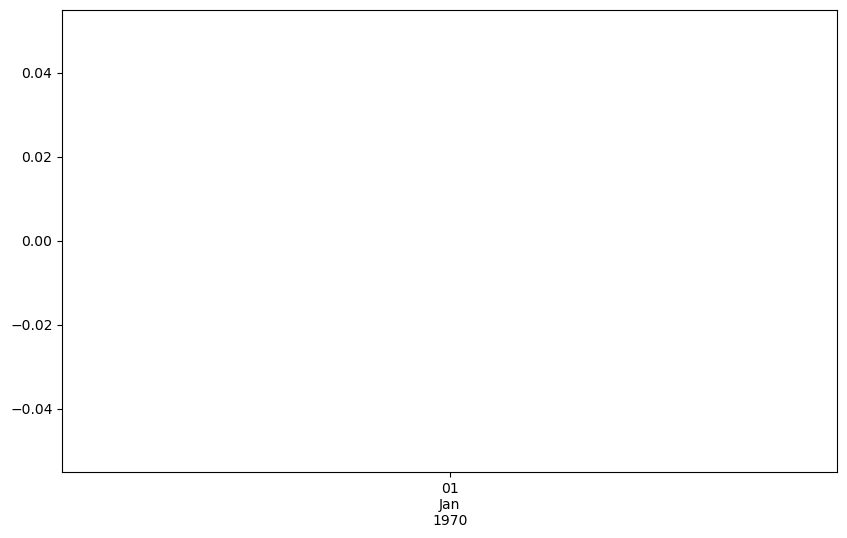

In [43]:
#For year 2019, plot all SWE_cm columns
SWE_df = Hydro_df.loc['2024-10-01':'2025-09-30'].copy()

#select all columns with 'SWE_cm' in the name
SWE_df = SWE_df.loc[:, SWE_df.columns.str.contains('SWE_cm')]

#plot
SWE_df.plot(figsize=(10, 6))

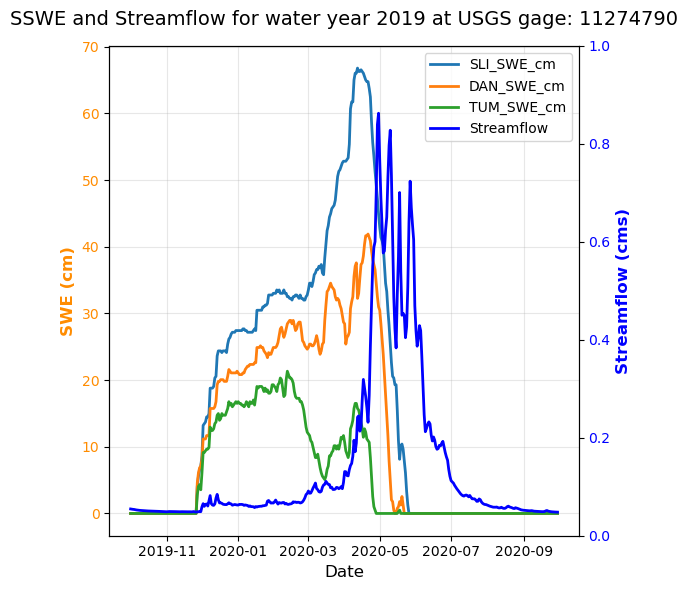

In [33]:
#plot the relationship between SWE_cm and flow_cms
#For year 2019, plot all SWE_cm columns
df = Hydro_df.loc['2019-10-01':'2020-09-30'].copy()

#select all columns with 'SWE_cm' and 'flow_cms' in the name
df = df.loc[:, df.columns.str.contains('SWE_cm') | df.columns.str.contains('flow_cms')]

#get colum names that contain SWE_cm
swe_cols = df.columns[df.columns.str.contains('SWE_cm')]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('SWE (cm)', color='darkorange', fontsize=12, fontweight='bold')
for swe in swe_cols:    
    ax1.plot(df.index, df[swe], linewidth=2, label = swe)

ax1.plot(df.index, df.flow_cms, color='blue', linewidth=2, label='Streamflow') 
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.grid(True, alpha=0.3)
#make second axis for streamflow
ax2 = ax1.twinx()
ax2.set_ylabel('Streamflow (cms)', color='blue', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

#show a legend
ax1.legend()

# Title and Layout
plt.title('SSWE and Streamflow for water year 2019 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()


In [34]:
df.columns

Index(['SLI_SWE_cm', 'DAN_SWE_cm', 'TUM_SWE_cm', 'flow_cms'], dtype='object')

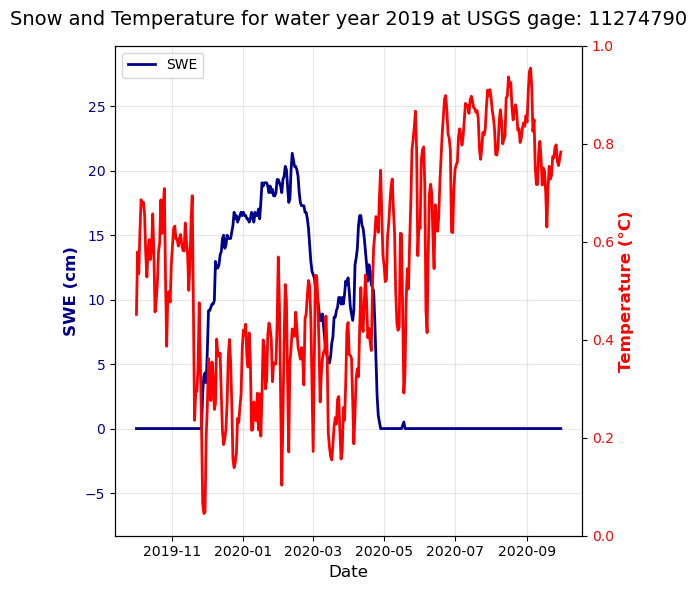

In [35]:
#plot the relationship between SWE_cm and temperature
#For year 2019, plot all SWE_cm columns
df = Hydro_df.loc['2019-10-01':'2020-09-30'].copy()

#get colum names that contain SWE_cm
swe_cols = df.columns[df.columns.str.contains('SWE_cm')]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('SWE (cm)', color='darkblue', fontsize=12, fontweight='bold')
#for swe in swe_cols:    
ax1.plot(df.index, df.TUM_SWE_cm, linewidth=2, label = 'SWE', color='darkblue')
ax1.plot(df.index, df.tmax_C, color='red', linewidth=2)

ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.grid(True, alpha=0.3)
#make second axis for streamflow
ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

#show a legend
ax1.legend()

# Title and Layout
plt.title('Snow and Temperature for water year 2019 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()


In [36]:
Hydro_df.columns

Index(['SLI_SWE_cm', 'DAN_SWE_cm', 'TUM_SWE_cm', 'prcp_mm_day', 'tmax_C',
       'tmin_C', 'tmean', 'site_no', 'flow_cms'],
      dtype='object')

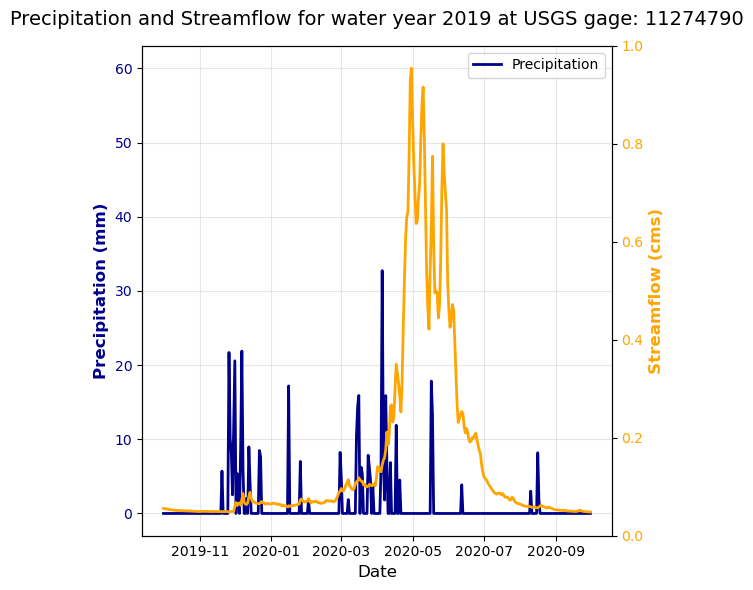

In [37]:
#plot the relationship between streamflow and precipitation
#For year 2019, plot all SWE_cm columns
df = Hydro_df.loc['2019-10-01':'2020-09-30'].copy()

#get colum names that contain SWE_cm
swe_cols = df.columns[df.columns.str.contains('SWE_cm')]

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Precipitation (mm)', color='darkblue', fontsize=12, fontweight='bold')
#for swe in swe_cols:    
ax1.plot(df.index, df.prcp_mm_day, linewidth=2, label = 'Precipitation', color='darkblue')
ax1.plot(df.index, df.flow_cms, color='orange', linewidth=2)

ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.grid(True, alpha=0.3)
#make second axis for streamflow
ax2 = ax1.twinx()
ax2.set_ylabel('Streamflow (cms)', color='orange', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='orange')

#show a legend
ax1.legend()

# Title and Layout
plt.title('Precipitation and Streamflow for water year 2019 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()
